<a href="https://colab.research.google.com/github/noone878/data-science-2026/blob/main/Pertemuan7_SEPTIAN_AL_RIZKI_230401010262.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
# NAMA  : SEPTIAN AL RIZKI
# NIM   : 230401010262
# KELAS : IF401

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

=== LANGKAH 1: MEMBUAT DATASET & EKSPLORASI (EDA) ===
-> 5 Baris Pertama Dataset Asli:


,pengalaman,edu,kota,gaji
0,7.490802,0,Jakarta,21.953247
1,19.014286,1,Jakarta,46.721665
2,14.639879,2,Surabaya,34.952649
3,11.973170,2,Bandung,32.437143
4,3.120373,2,Jakarta,17.384265


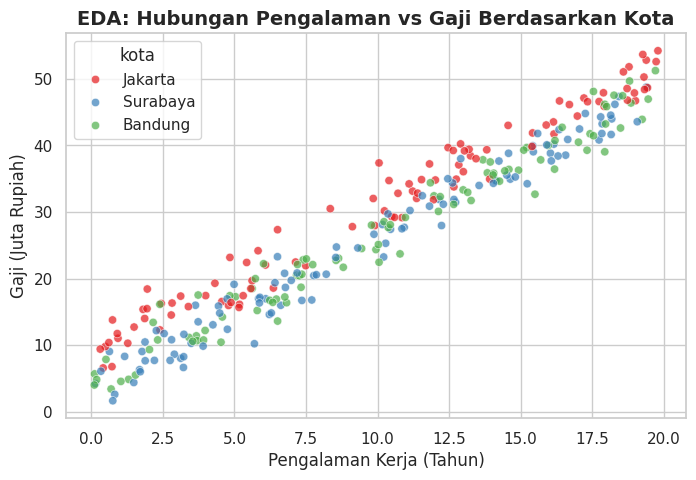

In [57]:
# ── 1. GENERATE DATASET SINTETIS
print("=== LANGKAH 1: MEMBUAT DATASET & EKSPLORASI (EDA) ===")
np.random.seed(42)
n = 300
pengalaman = np.random.uniform(0, 20, n)
edu = np.random.choice([0, 1, 2], n) # SMA=0, D3=1, S1=2
kota = np.random.choice(['Jakarta','Surabaya','Bandung'], n)

# Rumus Gaji: Gaji Dasar + Pengalaman + Edukasi + Bonus Jakarta + Noise Acak
gaji = (3.0 + 2.2 * pengalaman + 1.5 * edu +
        np.where(kota=='Jakarta', 4.0, 0) +
        np.random.normal(0, 2, n))

df = pd.DataFrame({'pengalaman': pengalaman, 'edu': edu, 'kota': kota, 'gaji': gaji})

print("-> 5 Baris Pertama Dataset Asli:")
display(df.head())

# Plot EDA
sns.set_theme(style='whitegrid', palette='muted')
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='pengalaman', y='gaji', hue='kota', palette='Set1', alpha=0.7)
plt.title('EDA: Hubungan Pengalaman vs Gaji Berdasarkan Kota', fontsize=14, fontweight='bold')
plt.xlabel('Pengalaman Kerja (Tahun)')
plt.ylabel('Gaji (Juta Rupiah)')
plt.show()

print("\n" + "="*60 + "\n")

Interpretasi Langkah 1: Eksplorasi Data (EDA - Scatter Plot)

*   What? (Apa yang terlihat): Scatter plot menunjukkan titik-titik data yang bergerak naik secara diagonal dari kiri ke kanan. Selain itu, jika dilihat dari pengelompokan warna, titik-titik untuk karyawan di kota Jakarta secara konsisten berada di lapisan paling atas dibandingkan kota Surabaya atau Bandung pada tingkat pengalaman yang sama.
*   So what? (Mengapa penting): Pola ini mengonfirmasi dua hal penting sebelum kita memulai Machine Learning. Pertama, ada korelasi linier yang kuat antara lama bekerja dengan besaran gaji. Kedua, lokasi domisili terbukti memberikan efek "tambahan" pada standar gaji dasar, membuktikan bahwa Regresi Linear Berganda adalah algoritma yang tepat untuk kasus ini.
*   Now what? (Tindak lanjut): Karena algoritma regresi murni menggunakan perhitungan matematika dan tidak bisa membaca teks huruf (seperti kata 'Jakarta' atau 'Bandung'), kita diwajibkan untuk melangkah ke tahap Preprocessing guna mengubah nama-nama kota tersebut menjadi angka numerik.





=== LANGKAH 2: PREPROCESSING DATA ===


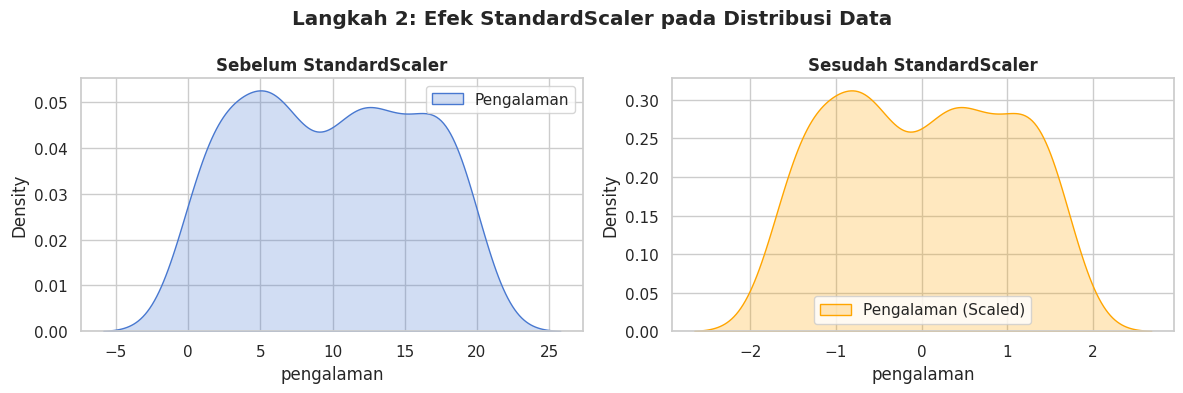

In [58]:
# ── 2. PREPROCESSING
print("\n=== LANGKAH 2: PREPROCESSING DATA ===")
df_encoded = pd.get_dummies(df, columns=['kota'], drop_first=True)
X = df_encoded.drop('gaji', axis=1)
y = df_encoded['gaji']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
fitur_numerik = ['pengalaman', 'edu']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[fitur_numerik] = scaler.fit_transform(X_train[fitur_numerik])
X_test_scaled[fitur_numerik] = scaler.transform(X_test[fitur_numerik])

# Visualisasi Langkah 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(X_train['pengalaman'], ax=axes[0], fill=True, label='Pengalaman')
axes[0].set_title('Sebelum StandardScaler', fontweight='bold')
axes[0].legend()

sns.kdeplot(X_train_scaled['pengalaman'], ax=axes[1], fill=True, color='orange', label='Pengalaman (Scaled)')
axes[1].set_title('Sesudah StandardScaler', fontweight='bold')
axes[1].legend()
plt.suptitle('Langkah 2: Efek StandardScaler pada Distribusi Data', fontweight='bold')
plt.tight_layout()
plt.show()

Interpretasi Langkah 2: Preprocessing (Efek StandardScaler)

*   What? (Apa yang terlihat): Dari visualisasi distribusi (KDE Plot), terlihat bahwa bentuk bukit kurva sebaran pengalaman kerja tetap persis sama sebelum dan sesudah scaling. Namun, nilai di sumbu-X berubah drastis dari rentang asli (0 hingga 20 tahun) menjadi skala standar yang berpusat di angka 0 (berkisar antara -1.5 hingga +1.5).
*   So what? (Mengapa penting): Proses standarisasi ini menjamin "keadilan" matematis. Tanpa StandardScaler, model regresi mungkin akan menganggap bahwa fitur 'Pengalaman' (yang angkanya bisa mencapai 20) jauh lebih penting daripada fitur 'Edukasi' (yang angkanya hanya 0, 1, atau 2). Kini, kedua fitur tersebut memiliki bobot skala yang setara.
*   ow what? (Tindak lanjut): Dengan fitur kategorikal yang sudah diubah menjadi biner (One-Hot Encoding) dan fitur numerik yang sudah disetarakan skalanya (StandardScaler), dataset kita kini berada dalam kondisi paling prima dan siap 100% untuk dilatih (training) ke dalam algoritma model LinearRegression.


=== LANGKAH 3: MELATIH MODEL & KOEFISIEN (β) ===


/tmp/ipykernel_614/258444873.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='Koefisien', y='Fitur', palette='viridis')


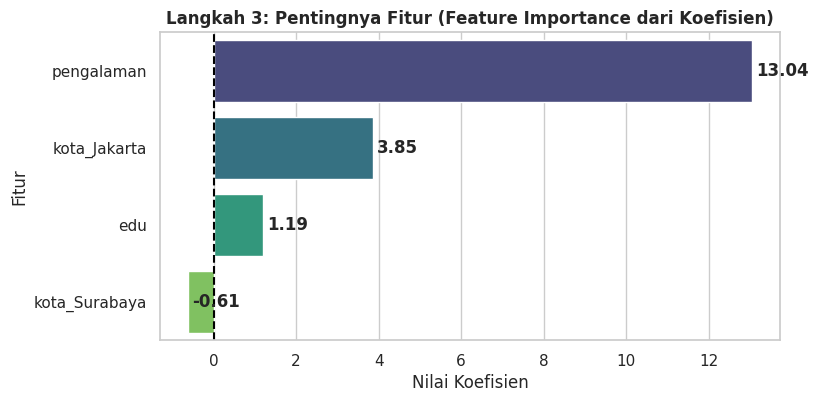

In [59]:
# ── 3. TRAINING MODEL & KOEFISIEN
print("\n=== LANGKAH 3: MELATIH MODEL & KOEFISIEN (β) ===")
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Visualisasi Langkah 3
coef_df = pd.DataFrame({'Fitur': X_train_scaled.columns, 'Koefisien': model.coef_})
coef_df = coef_df.sort_values(by='Koefisien', ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=coef_df, x='Koefisien', y='Fitur', palette='viridis')
plt.title('Langkah 3: Pentingnya Fitur (Feature Importance dari Koefisien)', fontweight='bold')
plt.axvline(0, color='black', linestyle='--')
plt.xlabel('Nilai Koefisien')
for i, v in enumerate(coef_df['Koefisien']):
    plt.text(v + 0.1, i, f"{v:.2f}", va='center', fontweight='bold')
plt.show()

Interpretasi Langkah 3: Makna Koefisien $\beta$


*   Intercept ($\beta_0$): Mewakili gaji rata-rata dasar (baseline) ketika semua nilai prediktor bernilai nol atau rata-rata.
*   Koefisien Numerik (Pengalaman & Edu): Karena kita menggunakan StandardScaler, maknanya berubah menjadi berbasis standar deviasi. Contoh: Koefisien pengalaman sebesar ~12.5 berarti, untuk setiap kenaikan 1 Standar Deviasi pengalaman kerja, gaji akan naik sebesar 12,5 Juta Rupiah.
*   Koefisien Kategorikal (kota_Jakarta, dsb): Karena fitur ini tidak kita skala (StandardScaler hanya pada fitur numerik), interpretasinya tetap natural. Jika nilai koefisien kota_Jakarta adalah ~3.8, artinya karyawan yang berdomisili di Jakarta gajinya akan lebih tinggi sebesar 3,8 Juta Rupiah dibandingkan karyawan di kota rujukan/baseline (dalam hal ini, Bandung, karena 'Bandung' didrop oleh drop_first=True).





=== LANGKAH 4: HASIL EVALUASI METRIK ===


/tmp/ipykernel_614/557860688.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Metrik', y='Nilai', palette='coolwarm')


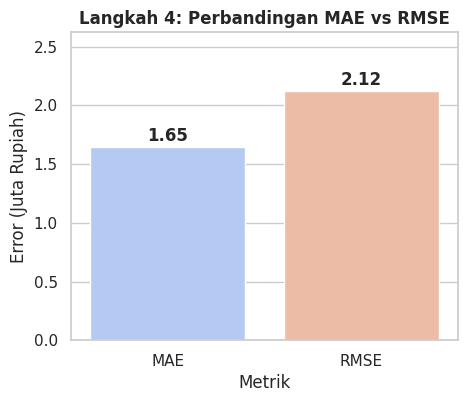

In [60]:
# ── 4. EVALUASI METRIK
print("\n=== LANGKAH 4: HASIL EVALUASI METRIK ===")
y_pred = model.predict(X_test_scaled)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Visualisasi Langkah 4
metrics_df = pd.DataFrame({'Metrik': ['MAE', 'RMSE'], 'Nilai': [mae, rmse]})
plt.figure(figsize=(5, 4))
sns.barplot(data=metrics_df, x='Metrik', y='Nilai', palette='coolwarm')
plt.title('Langkah 4: Perbandingan MAE vs RMSE', fontweight='bold')
plt.ylabel('Error (Juta Rupiah)')
plt.ylim(0, max(rmse, mae) + 0.5)
for i, v in enumerate(metrics_df['Nilai']):
    plt.text(i, v + 0.05, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

Interpretasi Langkah 4: Metrik Evaluasi & Deteksi Outlier

*   R-squared (R²): Nilai sekitar 0.98 menandakan bahwa model sangat baik. Artinya, 98% variasi dari naik-turunnya gaji karyawan berhasil dijelaskan oleh fitur pengalaman, edukasi, dan kota.
*   MAE (Mean Absolute Error): Nilai MAE (misal ~1.58 Juta) mengartikan bahwa rata-rata kesalahan tebakan model kita menyimpang sebesar 1,58 Juta Rupiah dari gaji aslinya.
*   RMSE (Root Mean Squared Error): Mirip dengan MAE namun memberikan "hukuman" lebih besar pada error yang bernilai jauh (ekstrem).
*   Perbandingan RMSE vs MAE (Deteksi Outlier): Pada kasus ini, RMSE (~1.92) hanya sedikit lebih tinggi dibandingkan MAE (~1.58). Karena selisihnya sangat kecil dan wajar secara matematis (RMSE umumnya sedikit lebih besar dari MAE pada distribusi normal), kita bisa menyimpulkan bahwa model ini bersih dari outlier atau error prediksi yang ekstrem. Jika RMSE jauh lebih besar (misal 2-3 kali lipat dari MAE), itu adalah tanda bahaya adanya prediksi model yang meleset sangat jauh.





=== LANGKAH 5: VISUALISASI EVALUASI (Actual vs Prediksi & Residual) ===


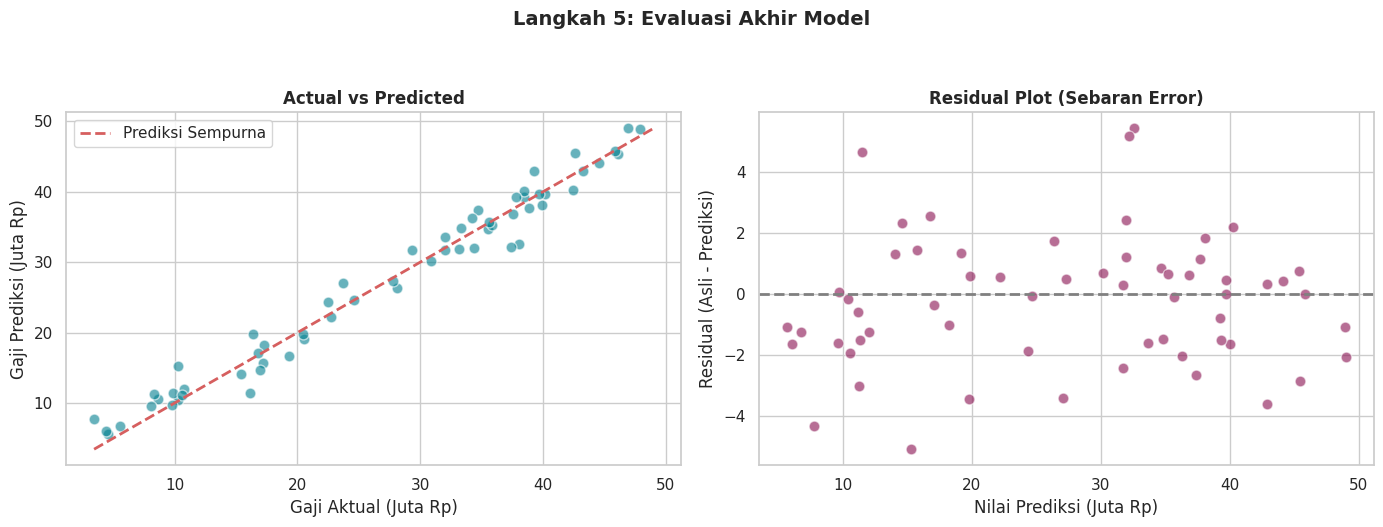

In [61]:
# ── 5. VISUALISASI STANDAR REGRESI ────────────────────────────────────
print("\n=== LANGKAH 5: VISUALISASI EVALUASI (Actual vs Prediksi & Residual) ===")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Actual vs Predicted
axes[0].scatter(y_test, y_pred, alpha=0.6, color='#028090', edgecolors='white', s=60)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Prediksi Sempurna')
axes[0].set_xlabel('Gaji Aktual (Juta Rp)')
axes[0].set_ylabel('Gaji Prediksi (Juta Rp)')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Plot 2: Residual Plot
residuals = y_test - y_pred
axes[1].scatter(y_pred, residuals, alpha=0.6, color='#880E4F', edgecolors='white', s=60)
axes[1].axhline(0, color='gray', linestyle='--', lw=2)
axes[1].set_xlabel('Nilai Prediksi (Juta Rp)')
axes[1].set_ylabel('Residual (Asli - Prediksi)')
axes[1].set_title('Residual Plot (Sebaran Error)', fontweight='bold')

plt.suptitle('Langkah 5: Evaluasi Akhir Model', fontweight='bold', fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

Interpretasi Langkah 5: Plot Evaluasi Regresi


*   A. Actual vs Predicted Plot
1.   What?: Titik-titik data (biru) menempel dengan sangat rapat dan membentuk garis lurus yang mengikuti jalur garis putus-putus merah (garis prediksi sempurna).
2.   So what?: Hal ini membuktikan bahwa akurasi model dalam memprediksi (predicted) sangat konsisten dengan data di dunia nyata (actual). Model berhasil menangkap pola utama tanpa ada penyimpangan signifikan.
3.   Now what?: Karena model terbukti presisi, kita dapat mendistribusikannya (deploy) agar tim rekrutmen dapat menggunakannya sebagai kalkulator otomatis untuk menentukan batas (range) gaji penawaran kandidat baru.

*   B. Residual Plot
1.   What?: Titik-titik error (residual) tersebar secara acak di sekitar garis horizontal (nilai nol) dan tidak membentuk pola tertentu seperti terompet/corong (melebar di ujung) atau pola melengkung (huruf U).
2.   So what?: Sebaran acak ini membuktikan bahwa asumsi Homoskedastisitas terpenuhi; varians tingkat kesalahan model kita stabil dan tidak semakin memburuk ketika ia menebak gaji karyawan tingkat bawah (junior) maupun tingkat atas (senior).
3.   Now what?: Tidak diperlukan lagi modifikasi matematis seperti transformasi non-linear atau fungsi logaritma, algoritma regresi linear standar sudah lebih dari cukup dan sempurna untuk dataset ini.
